# **EXPLORATORY DATA ANALYSIS (EDA) & DATA PREPROCESSING**

Overview of the dataset "Coffee Shop Sales.csv"

  * **transaction_id**: Transaction ID.
  * **transaction_date**: Transaction date.
  * **transaction_time**: Transaction time.
  * **transaction_qty**: Transaction quantity.
  * **store_id**: Store ID.
  * **store_location**: Store location.
  * **product_id**: Product ID.
  * **unit_price**: Unit price.
  * **product_category**: Product category.
  * **product_type**: Product type.
  * **product_detail**: Product details.

## **1. Data Initialization and Loading**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel('Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## **2. Data Quality Check**

In [30]:
print("1. Checking Missing Values:")
print(df.isnull().sum())

print("\n2. Checking Duplicate Records:")
print(df.duplicated().sum())

print("\n3. Checking Negative Values (Logic Check):")
print("Số lượng âm:", len(df[df['transaction_qty'] < 0]))
print("Đơn giá âm:", len(df[df['unit_price'] < 0]))

print("\n4. Checking Datetime Data Types:")
display(df[['transaction_date', 'transaction_time']].dtypes)

1. Checking Missing Values:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

2. Checking Duplicate Records:
0

3. Checking Negative Values (Logic Check):
Số lượng âm: 0
Đơn giá âm: 0

4. Checking Datetime Data Types:


,0
transaction_date,datetime64[ns]
transaction_time,object


**Observation:**

- The dataset contains no missing values, no duplicate records, and no negative values.

## **3. Feature Grouping and Unique Value Analysis**

In [31]:
# Phân các đặc trưng dạng số và dạng phân loại
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numeric Columns:", numeric_columns)

# Tìm các giá trị unique của mỗi loại đặc trưng
print("\n--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (UNIQUE) ---")
print("\n1. Đặc trưng phân loại:")
print(df[categorical_columns].nunique())

print("\n2. Đặc trưng số:")
print(df[numeric_columns].nunique())

Categorical Columns: ['transaction_time', 'store_location', 'product_category', 'product_type', 'product_detail']
Numeric Columns: ['transaction_id', 'transaction_qty', 'store_id', 'product_id', 'unit_price']

--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (UNIQUE) ---

1. Đặc trưng phân loại:
transaction_time    25762
store_location          3
product_category        9
product_type           29
product_detail         80
dtype: int64

2. Đặc trưng số:
transaction_id     149116
transaction_qty         6
store_id                3
product_id             80
unit_price             41
dtype: int64


In [32]:
# In ra các giá trị unique của đặc trưng dạng phân loại:
for column in categorical_columns:
    print(f"\nCác giá trị duy nhất của cột '{column}':")
    print(df[column].unique())


Các giá trị duy nhất của cột 'transaction_time':
[datetime.time(7, 6, 11) datetime.time(7, 8, 56) datetime.time(7, 14, 4)
 ... datetime.time(10, 34, 30) datetime.time(12, 3, 24)
 datetime.time(16, 59, 49)]

Các giá trị duy nhất của cột 'store_location':
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Các giá trị duy nhất của cột 'product_category':
['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']

Các giá trị duy nhất của cột 'product_type':
['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']

Các 

## **4. Tiền xử lý dữ liệu (Data Cleaning & Feature Engineering)**

In [33]:
# Tạo bản sao
df_copy = df.copy()

# 1. Điền giá trị khuyết (Fillna) cho các cột số bằng giá trị trung bình
df_copy.fillna(df_copy.mean(numeric_only=True), inplace=True)

# 2. Xóa các dòng trùng lặp
df_copy.drop_duplicates(inplace=True)

# 3. Ép kiểu dữ liệu (Type Casting) cho đúng định dạng thời gian
df_copy['transaction_date'] = pd.to_datetime(df_copy['transaction_date'])
df_copy['transaction_time'] = pd.to_datetime(df_copy['transaction_time'], format='%H:%M:%S', errors='coerce')

# 4. Feature Engineering: Tạo các đặc trưng mới cho phân tích kinh doanh
df_copy['Revenue'] = df_copy['transaction_qty'] * df_copy['unit_price']
df_copy['Hour'] = df_copy['transaction_time'].dt.hour
df_copy['Day'] = df_copy['transaction_date'].dt.day_name()
df_copy['Month'] = df_copy['transaction_date'].dt.month_name()
df_copy['Year'] = df_copy['transaction_date'].dt.year

display(df_copy[['transaction_date', 'transaction_time', 'Revenue', 'Hour']].head())

,transaction_date,transaction_time,Revenue,Hour
0,2023-01-01,1900-01-01 07:06:11,6.0,7
1,2023-01-01,1900-01-01 07:08:56,6.2,7
2,2023-01-01,1900-01-01 07:14:04,9.0,7
3,2023-01-01,1900-01-01 07:20:24,2.0,7
4,2023-01-01,1900-01-01 07:22:41,6.2,7


## **5. Kiểm tra và Xử lý Ngoại lai (Outliers)**

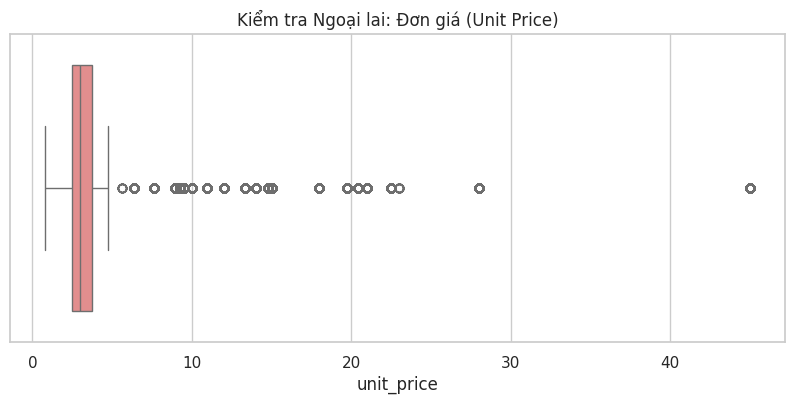

In [34]:
# Vẽ Boxplot để phát hiện Outlier của Đơn giá
plt.figure(figsize=(10, 4))
sns.boxplot(x='unit_price', data=df_copy, color='lightcoral')
plt.title('Kiểm tra Ngoại lai: Đơn giá (Unit Price)')
plt.show()

**Nhận xét:** Có 1 điểm ngoại lai với giá trị lớn hơn 40.

**=> Next Action:** Cần xử lý điểm này.

In [35]:
# XỬ LÝ OUTLIER:
df_clean = df_copy[df_copy['unit_price'] <= 40].copy()
print(f"Số dòng dữ liệu sau khi lọc Outlier: {len(df_clean)} (Đã xóa {len(df_copy) - len(df_clean)} dòng)")

Số dòng dữ liệu sau khi lọc Outlier: 148926 (Đã xóa 190 dòng)


## **6. Khám phá dữ liệu (EDA) với dữ liệu đã làm sạch**


### **6.1. Phân phối Danh mục và Vị trí (Categorical)**

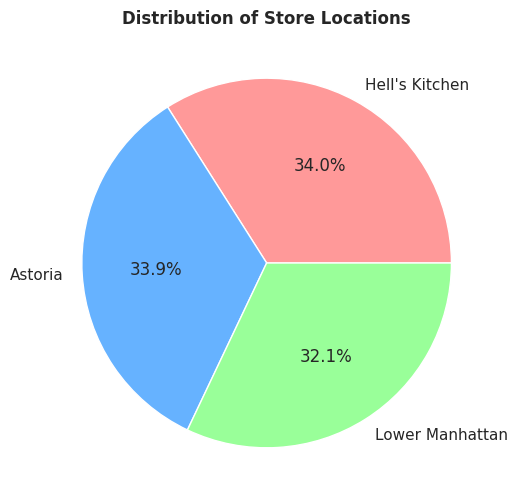

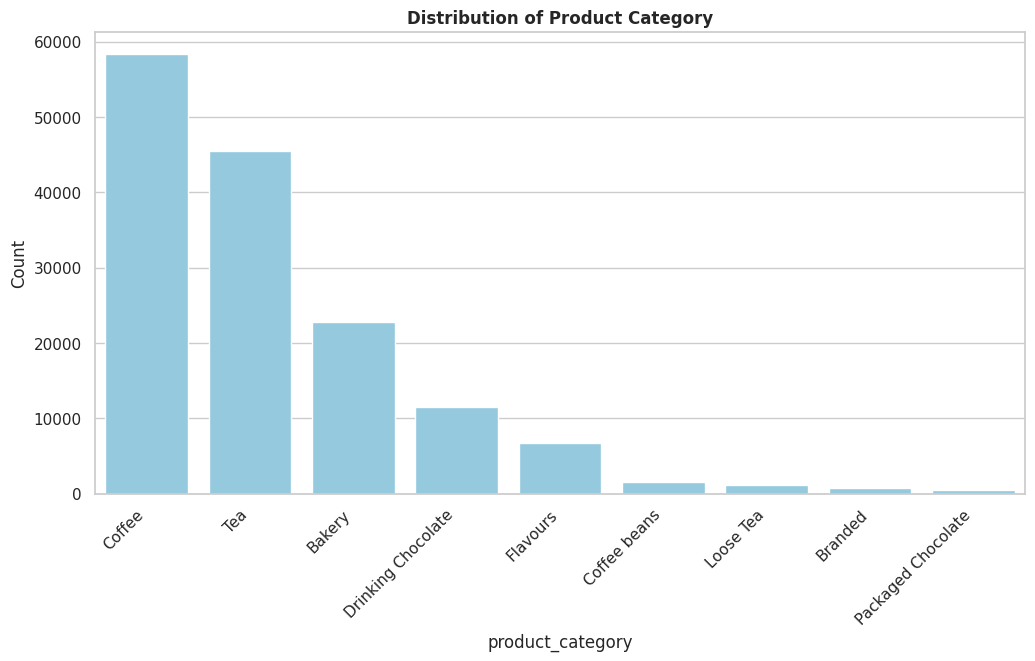

In [36]:
# Tỷ lệ vị trí cửa hàng
plt.figure(figsize=(8, 6))
colors = ['#FF9999', '#66B2FF', '#99FF99']
plt.pie(df_clean['store_location'].value_counts(),
        labels=df_clean['store_location'].value_counts().index,
        autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Store Locations', fontweight='bold')
plt.show()

# Phân phối Danh mục sản phẩm
plt.figure(figsize=(12, 6))
sns.barplot(x=df_clean['product_category'].value_counts().index,
            y=df_clean['product_category'].value_counts().values,
            color='skyblue')
plt.title('Distribution of Product Category', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.show()

**Nhận xét:**
- Số giao dịch ở ba store location có phân phối khá đều khoảng 32-34%.
- Món mà đặt hàng nhiều nhất ở các tiệm cà phê là coffee, trà và bánh, lần lượt là khoảng gần 60000, 45000 và 20000 đơn có món đó.

**=> Next action:** Phân tích sâu hơn các đặc trưng số.

### **6.2. Phân phối Số lượng và Đơn giá (Numerical)**

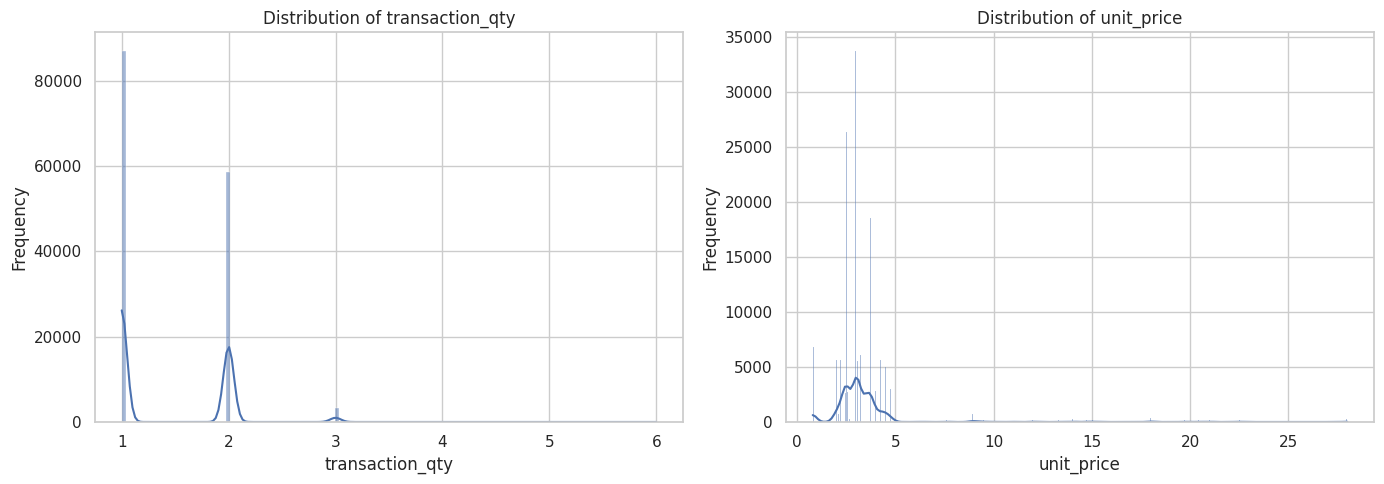

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['transaction_qty'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of transaction_qty')
axes[0].set_ylabel('Frequency')

sns.histplot(df_clean['unit_price'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of unit_price')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Số lượng giao dịch khoảng từ 1 đến 2 lần (chiếm hơn 80000 dòng và 60000 dòng), và số lần nhiều hơn thì khá ít.
- Các đơn giá là từ 1 tới 3 đơn vị mỗi lần giao dịch.

### **6.3. Doanh thu theo Sản phẩm & Thời gian**

In [38]:
import warnings
warnings.filterwarnings('ignore')
# Thống kê số lượng giao dịch
time_check = df_clean.groupby(df_clean['transaction_date'].dt.strftime('%Y-%m')).size().reset_index(name='Số lượng')
time_check.columns = ['Năm-Tháng', 'Số lượng giao dịch']

print("====== THỐNG KÊ SỐ LƯỢNG GIAO DỊCH ======")
print(time_check.to_string(index=False))

====== THỐNG KÊ SỐ LƯỢNG GIAO DỊCH ======
Năm-Tháng  Số lượng giao dịch
  2023-01               17291
  2023-02               16338
  2023-03               21202
  2023-04               25305
  2023-05               33487
  2023-06               35303


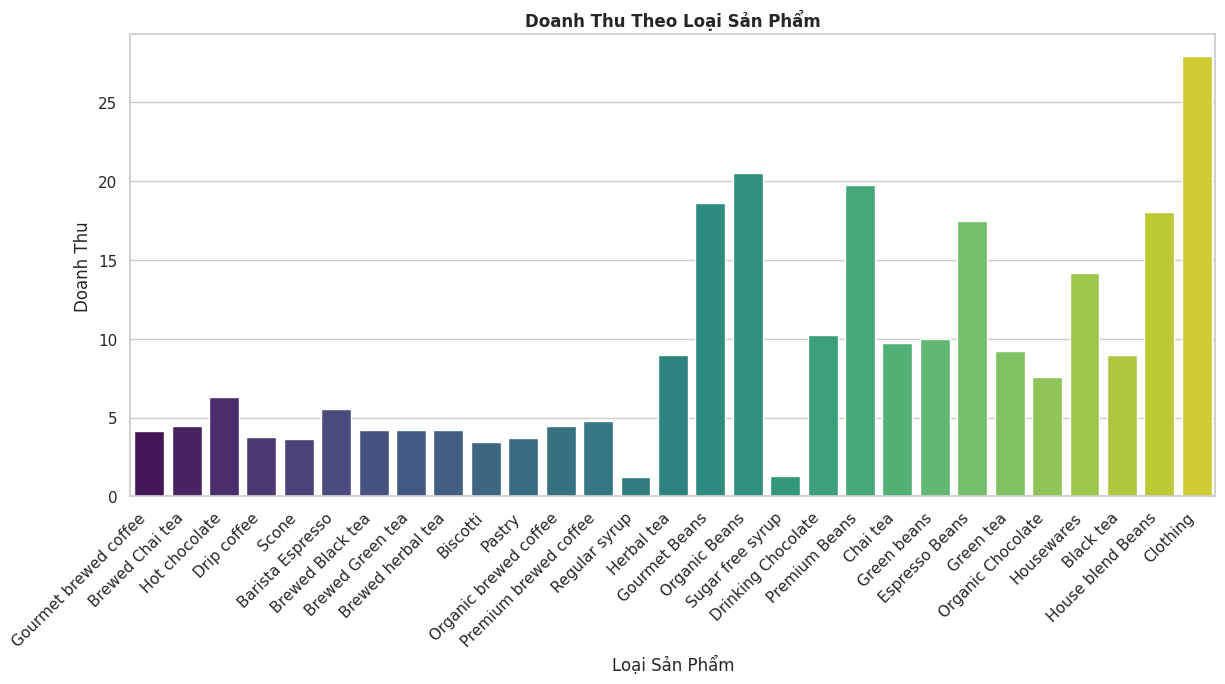

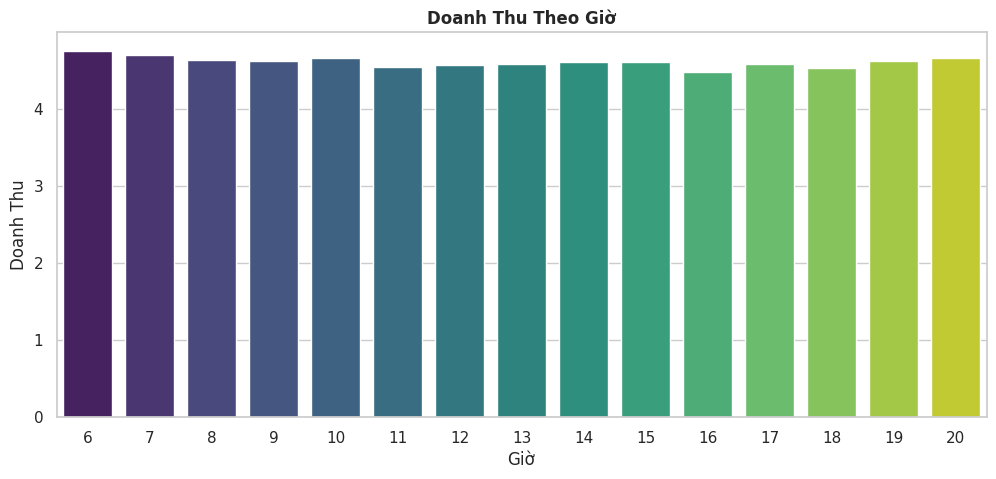

In [39]:
# Doanh thu theo loại sản phẩm
plt.figure(figsize=(14, 6))
sns.barplot(x='product_type', y='Revenue', data=df_clean, palette='viridis', errorbar=None)
plt.title('Doanh Thu Theo Loại Sản Phẩm', fontweight='bold')
plt.xlabel('Loại Sản Phẩm')
plt.ylabel('Doanh Thu')
plt.xticks(rotation=45, ha='right')
plt.show()

# Doanh thu theo khung giờ (Peak Hours)
plt.figure(figsize=(12, 5))
sns.barplot(data=df_clean, x='Hour', y='Revenue', palette='viridis', errorbar=None)
plt.title('Doanh Thu Theo Giờ', fontweight='bold')
plt.xlabel('Giờ')
plt.ylabel('Doanh Thu')
plt.show()

**Nhận xét:**
- Sản phẩm clothing có doanh thu lớn nhất (hơn 25 USD) => Sản phẩm bán chạy nhất. Và các sản phẩm bán chạy tiếp theo là Organic Beans và Premium Beans (gần 20 USD).

- Thời gian từ 6 đến 10 giờ sáng và từ 20 giờ tối trở đi là những thời điểm mà các quán cà phê bán chạy nhất. Thường là thời gian trước khi đi làm hoặc là buổi tối.

### **6.4. Sản phẩm bán chạy nhất trong từng Danh mục (Category)**

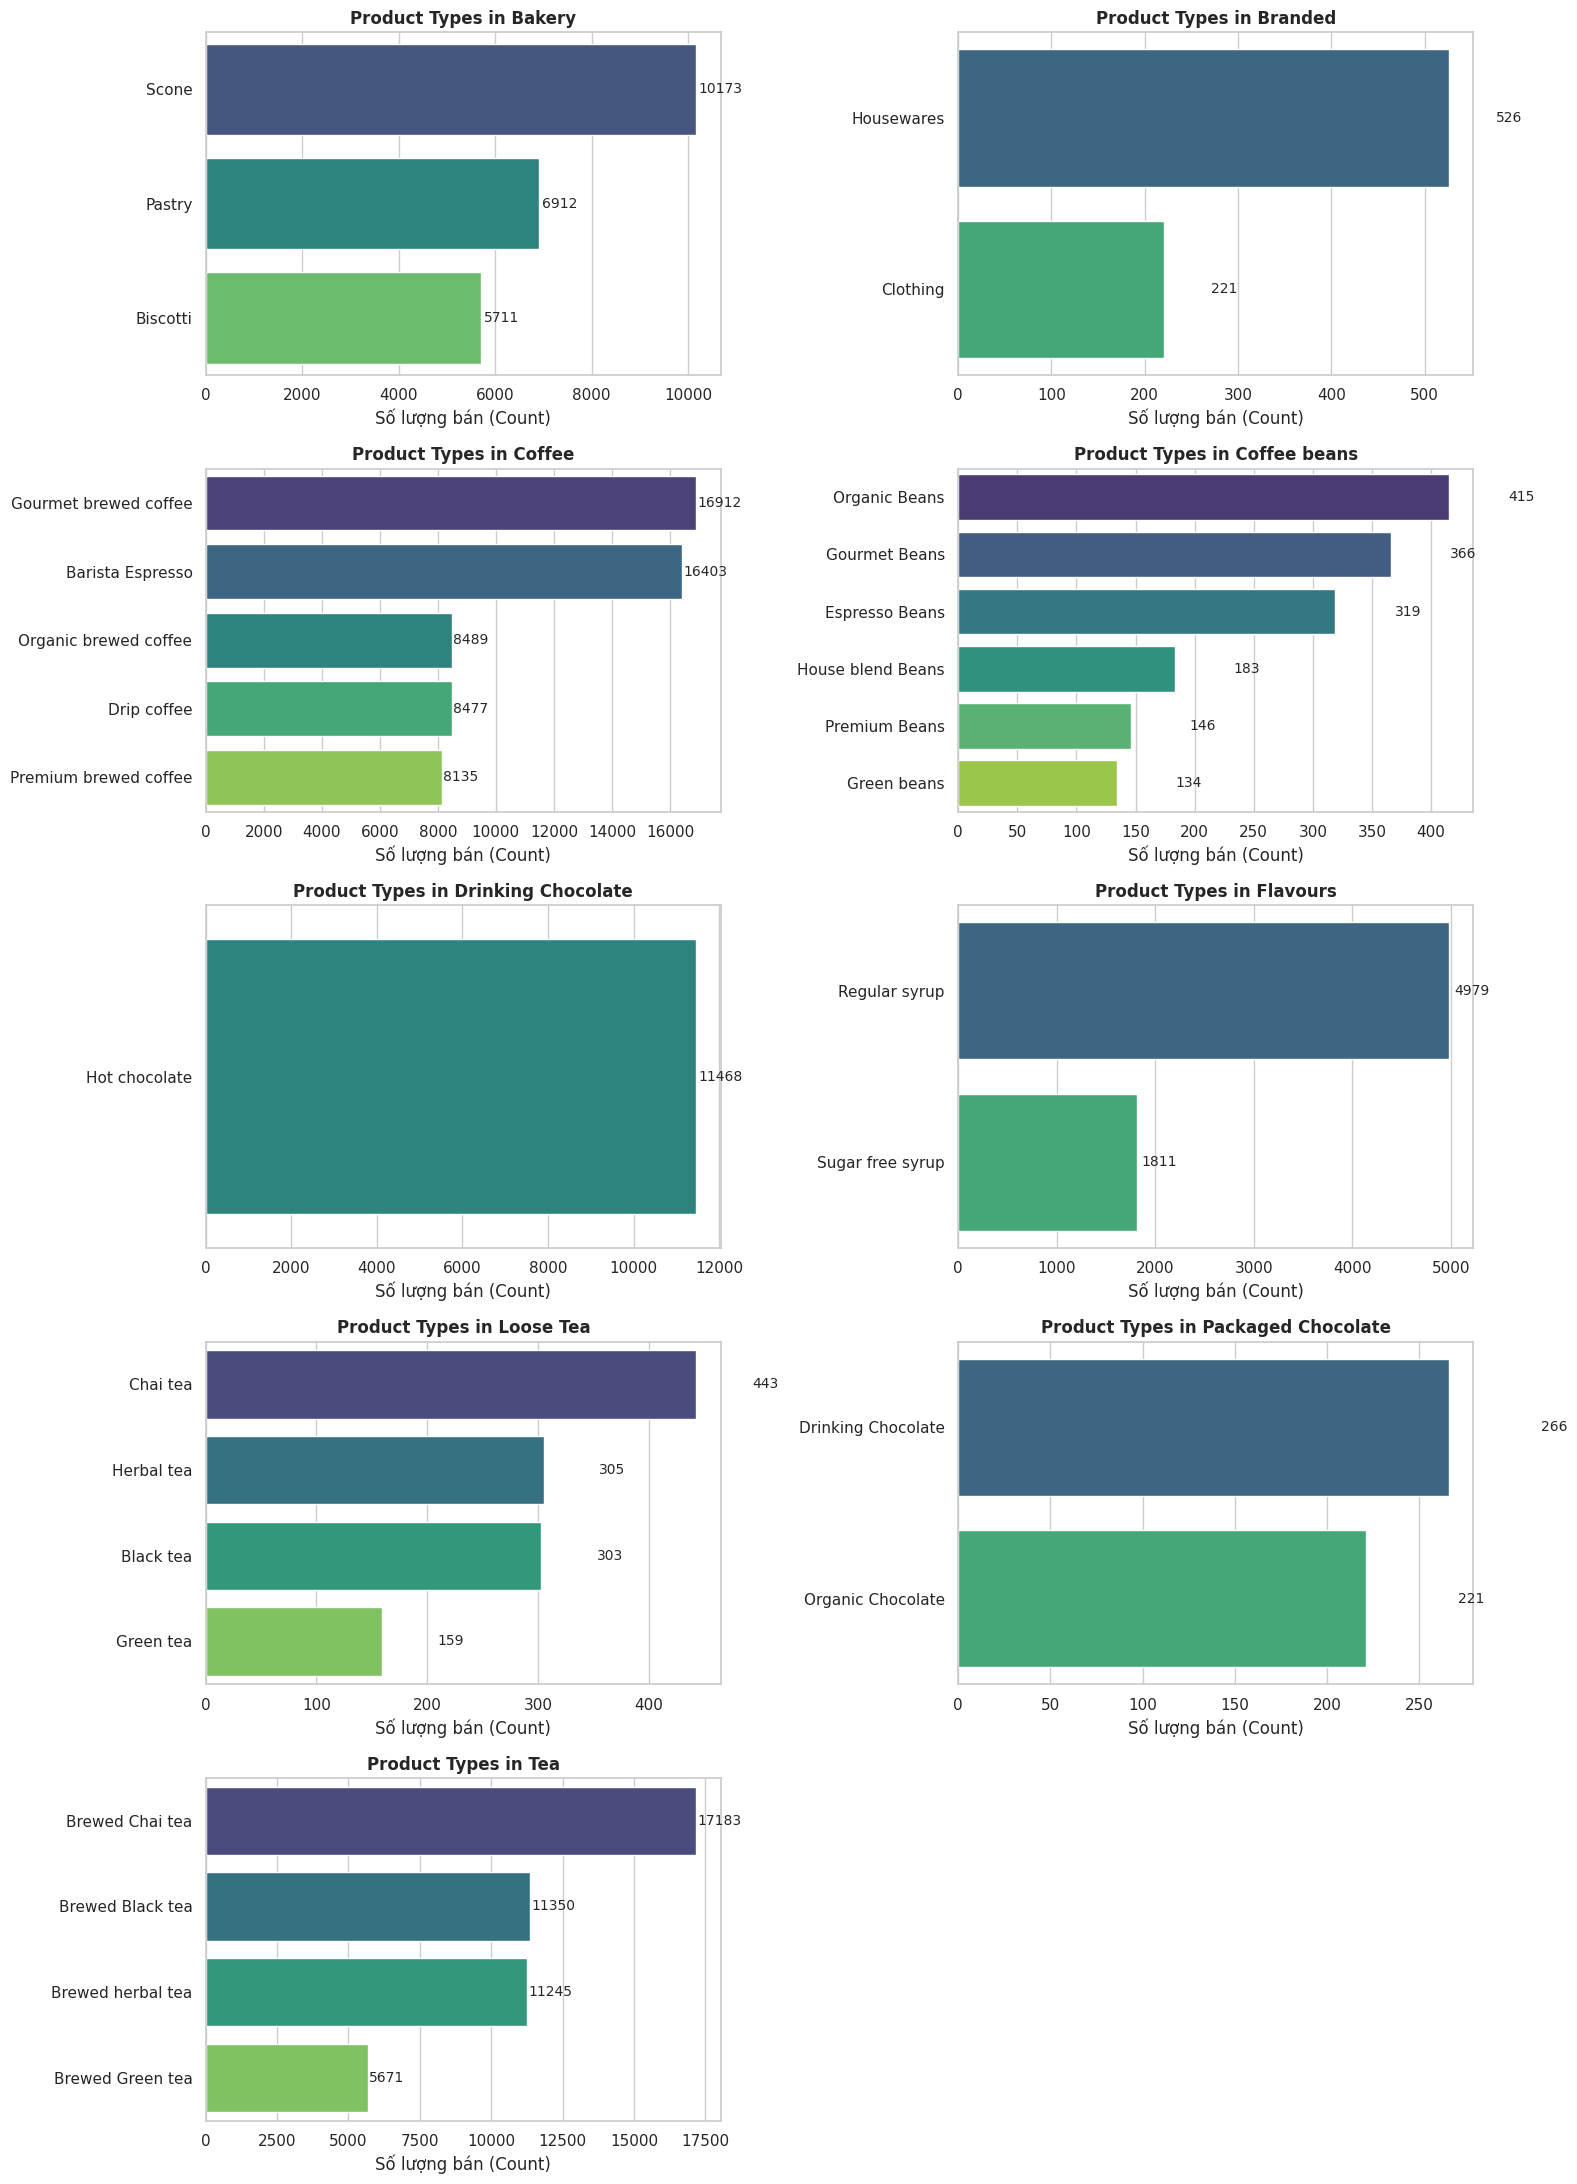

In [40]:
import warnings
warnings.filterwarnings('ignore')
# Gom nhóm đếm số lượng bán ra của từng Loại sản phẩm (product_type) trong mỗi Danh mục (product_category)
counts = df_clean.groupby(["product_category", "product_type"]).size().reset_index(name="count")
categories = counts['product_category'].unique()

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

# Vẽ biểu đồ cho từng Danh mục
for i, category in enumerate(categories):
    subset = counts[counts['product_category'] == category].sort_values('count', ascending=False)

    # Vẽ biểu đồ thanh ngang
    sns.barplot(x='count', y='product_type', data=subset, ax=axes[i], palette='viridis')

    axes[i].set_title(f'Product Types in {category}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Số lượng bán (Count)')
    axes[i].set_ylabel('')

    # Gắn nhãn số lượng trực tiếp lên từng bar
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 50, p.get_y() + p.get_height()/2, f'{int(width)}',
                     ha='left', va='center', fontsize=10)

# Ẩn các ô biểu đồ bị dư
for j in range(len(categories), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## **7. DATA CONCLUSIONS**
- **Year & Month:** Sales exclusively from 2023. Most sales within a six-month period.
- **Hour:** Most sales were from 6 am to 9 am and 20 pm.
- **Transaction quantity:** Most sales were singles followed by 2 lots.
- **Stores:** The sales rates of the three stores were similar, with the most significant difference observed at the Hell's Kitchen store.
- **Unit price:** Price distribution is positively skewed, we understand from this that most Coffee have lower prices, while a few Coffee have higher prices.
- **Category:** It's evident that the three stores offer a wide range of services. Coffee stands as the best-selling product. Tea also exhibits a high sales rate.
- **Product Type Highlights:**
  - Bakery: Most sold item is the scone.
  - Branded: Best-selling item is Housewares.
  - Coffee: Best-selling item is Gourmet brewed coffee.
  - Coffee beans: Best-selling item is Organic Beans.
  - Drinking Chocolate: Solely offers hot chocolate.
  - Flavours: Regular syrup are the top-selling items.
  - Loose Tea: Best-selling item is Chai tea.
  - Packaged Chocolate: Best-selling item is Drinking Chocolate.
  - Tea: Best-selling item is Brewed Chai tea.